# Flutterwave Risk Analytics Assessment

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# Importing data

In [2]:
df = pd.read_csv("/Users/mac/Downloads/flutterwave_synthetic_txs.csv")

#### Data Dictionary
- transaction_id: A unique, primary key identifier for each transaction.
- user_id: The identifier for the user initiating the transaction.
- timestamp: The time the transaction was processed.
- amount_usd: The transaction value in USD.
- card_country: The country of origin for the card used.
- merchant_category: The category of the merchant receiving the funds.
- device_id: The identifier of the device used for the transaction.
- dispute_status: The current resolution state of the transaction with the issuing bank.
- is_fraud: The target variable indicating that the transaction resulted in a fraud
chargeback (1 = Fraudulent, 0 = Legitimate).

# Part 1: Data Engineering & SQL

```sql
SELECT
    t1.transaction_id,
    t1.user_id,
    t1.timestamp,

    (
        SELECT SUM(t2.amount_usd)
        FROM flutterwave_synthetic_txs t2
        WHERE t2.user_id = t1.user_id
          AND t2.timestamp BETWEEN
              t1.timestamp - INTERVAL '24 hour'
              AND t1.timestamp
    ) AS total_amount_prev_24h,

    (
        SELECT COUNT(DISTINCT t2.card_country)
        FROM flutterwave_synthetic_txs t2
        WHERE t2.user_id = t1.user_id
          AND t2.timestamp BETWEEN
              t1.timestamp - INTERVAL '1 hour'
              AND t1.timestamp
    ) AS distinct_card_countries_prev_1h

FROM flutterwave_synthetic_txs t1;
```


Executing correlated subqueries for every transaction can become expensive on large transaction tables because the database will repeatedly scan historical records for each row.

To improve performance at scale, I would consider the following:

1. Partitioning the table by transaction date: This will reduce the amount of historical data scanned when calculating rolling windows.
2. Indexing / Sort Keys: I will create an index using (user_id, timestamp). Since the query filters by both user and transaction time, this can significantly improve lookup performance.
3. Use Window Functions Where Possible: Window functions are often more efficient than correlated subqueries for calculating rolling aggregates and can reduce query execution time on large datasets.
4. Incremental Feature Computation: Instead of recomputing features across the entire transaction history, only newly arriving transactions should be processed, reducing computational overhead and improving scalability.

# Part 2: Fraud Modeling

In [4]:
df.head()

,transaction_id,user_id,timestamp,amount_usd,card_country,merchant_category,device_id,dispute_status,is_fraud
0,3c4b12fa-07e5-4bc5-89f2-0fbbef5bb621,USR_7270,2026-05-24T07:56:29Z,13.03,NG,digital_goods,DEV_84432,none,0
1,45cec382-3988-4e49-9069-ec067fae3211,USR_9970,2026-05-30T00:00:04Z,25.45,NG,ecommerce,DEV_71903,none,0
2,f89e3f53-c7fa-44ab-8d4d-7e0f18e3ee85,USR_1927,2026-05-27T19:07:33Z,31.07,NG,digital_goods,DEV_43762,none,0
3,bdfa52db-f96a-4446-9108-fa5a415c1499,USR_2602,2026-05-06 21:49:19,36.46,NG,ecommerce,DEV_65740,none,0
4,724f928e-36f9-4018-9671-6c247c6f6000,USR_1434,2026-05-13T07:10:28Z,140.66,NG,travel,DEV_74609,none,0


# Data Inspection and Cleaning

In [5]:
df.shape

(52500, 9)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     52500 non-null  object 
 1   user_id            52500 non-null  object 
 2   timestamp          52500 non-null  object 
 3   amount_usd         52500 non-null  float64
 4   card_country       52500 non-null  object 
 5   merchant_category  52500 non-null  object 
 6   device_id          52500 non-null  object 
 7   dispute_status     52500 non-null  object 
 8   is_fraud           52500 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 3.6+ MB


As seen above, there is no missing values in the dataset and the data types of all the features were correctly identified except for timestamp, which ought to be a datetime object

In [8]:
df.timestamp.head(20)

0     2026-05-24T07:56:29Z
1     2026-05-30T00:00:04Z
2     2026-05-27T19:07:33Z
3      2026-05-06 21:49:19
4     2026-05-13T07:10:28Z
5     2026-05-01T07:01:53Z
6     2026-05-18T10:47:33Z
7     2026-05-22T12:14:07Z
8      2026-05-12 20:37:42
9     2026-05-29T06:57:47Z
10    2026-05-16T18:05:56Z
11    2026-05-26T11:29:29Z
12    2026-05-08T10:48:12Z
13     2026-05-05 13:05:20
14    2026-05-07T14:40:20Z
15    2026-05-23T22:46:10Z
16     2026-05-27 21:30:23
17    2026-05-23T06:00:58Z
18     2026-05-22 15:20:19
19     2026-05-05 17:21:19
Name: timestamp, dtype: object

The column preview above shows that some letters are erroneously inserted in the timestamp.

In [9]:
df['timestamp'] = (df['timestamp'].str.replace("T", " ")).str.replace("Z", "")
df['timestamp']

0        2026-05-24 07:56:29
1        2026-05-30 00:00:04
2        2026-05-27 19:07:33
3        2026-05-06 21:49:19
4        2026-05-13 07:10:28
                ...         
52495    2026-05-30 12:43:57
52496    2026-05-23 01:28:21
52497    2026-05-13 11:44:38
52498    2026-05-17 10:09:22
52499    2026-05-19 03:46:41
Name: timestamp, Length: 52500, dtype: object

In [10]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     52500 non-null  object        
 1   user_id            52500 non-null  object        
 2   timestamp          52500 non-null  datetime64[ns]
 3   amount_usd         52500 non-null  float64       
 4   card_country       52500 non-null  object        
 5   merchant_category  52500 non-null  object        
 6   device_id          52500 non-null  object        
 7   dispute_status     52500 non-null  object        
 8   is_fraud           52500 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 3.6+ MB


In [11]:
df.head()

,transaction_id,user_id,timestamp,amount_usd,card_country,merchant_category,device_id,dispute_status,is_fraud
0,3c4b12fa-07e5-4bc5-89f2-0fbbef5bb621,USR_7270,2026-05-24 07:56:29,13.03,NG,digital_goods,DEV_84432,none,0
1,45cec382-3988-4e49-9069-ec067fae3211,USR_9970,2026-05-30 00:00:04,25.45,NG,ecommerce,DEV_71903,none,0
2,f89e3f53-c7fa-44ab-8d4d-7e0f18e3ee85,USR_1927,2026-05-27 19:07:33,31.07,NG,digital_goods,DEV_43762,none,0
3,bdfa52db-f96a-4446-9108-fa5a415c1499,USR_2602,2026-05-06 21:49:19,36.46,NG,ecommerce,DEV_65740,none,0
4,724f928e-36f9-4018-9671-6c247c6f6000,USR_1434,2026-05-13 07:10:28,140.66,NG,travel,DEV_74609,none,0


In [12]:
df.tail()

,transaction_id,user_id,timestamp,amount_usd,card_country,merchant_category,device_id,dispute_status,is_fraud
52495,332f9b67-cfc4-4e02-9b16-2471474a99ed,USR_5828,2026-05-30 12:43:57,16.41,KE,utility,DEV_58207,none,0
52496,9a98adca-ad76-4daa-b8fb-ed4ecdd22995,USR_8012,2026-05-23 01:28:21,39.76,NG,digital_goods,DEV_42748,none,0
52497,0df42593-95b7-4d77-9f28-60ce25ff9862,USR_4768,2026-05-13 11:44:38,18.64,ZA,ecommerce,DEV_45832,inquiry,0
52498,8df56571-62a6-4a59-b557-f10352e707ee,USR_2300,2026-05-17 10:09:22,69.38,NG,utility,DEV_57597,none,0
52499,4b32c2b1-12d6-4baf-ab5d-070e587f6813,USR_9269,2026-05-19 03:46:41,24.87,NG,digital_goods,DEV_66819,none,0


# Exploratory Data Analysis

In [13]:
df.describe()

,timestamp,amount_usd,is_fraud
count,52500,52500.000000,52500.000000
mean,2026-05-16 01:34:01.127333376,54.795952,0.019048
min,2026-05-01 00:00:39,5.000000,0.000000
25%,2026-05-08 13:02:34.750000128,19.317500,0.000000
50%,2026-05-16 00:26:43.500000,39.560000,0.000000
75%,2026-05-23 14:06:05.249999872,74.030000,0.000000
max,2026-05-31 00:56:04,529.430000,1.000000
std,NaN,49.793381,0.136694


The dataset contains 52,500 transactions recorded between May 1 and May 31, 2026. Transaction amounts range from 5.00 usd to 529.43 usd, with an average value of approximately 54.80 usd and a median of 39.56 usd. The difference between the mean and median suggests the presence of some relatively high-value transactions.

The transaction amount distribution appears to be slightly right-skewed, indicating that a small number of large transactions may influence the average transaction value. Additionally, the average value of the `is_fraud` variable (0.019) indicates that fraudulent transactions represent a very small proportion of the dataset.

The distribution of transaction amounts will be examined further using histograms and boxplots to identify potential outliers. The class distribution of the target variable will also be assessed to determine whether class imbalance handling techniques may be required during model development.


In [14]:
df['is_fraud'].value_counts()

is_fraud
0    51500
1     1000
Name: count, dtype: int64

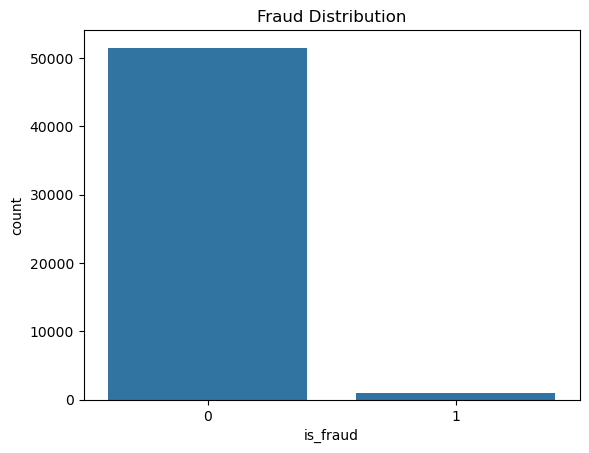

In [15]:
sns.countplot(data=df, x='is_fraud')

plt.title("Fraud Distribution")
plt.show()

In [16]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    98.095238
1     1.904762
Name: proportion, dtype: float64

The dataset contains 51,500 legitimate transactions and 1,000 fraudulent transactions, meaning fraudulent transactions account for approximately 1.9% of all observations.

This indicates a significant class imbalance. A predictive model trained on this data may become biased toward the majority class and achieve high accuracy while failing to effectively identify fraudulent transactions.

During model development, evaluation metrics such as Precision, Recall, F1-Score, and ROC-AUC will be prioritized over accuracy. Class imbalance mitigation technique such as class weighting will be applied to improve fraud detection performance.


## Distribution of Transaction Amount

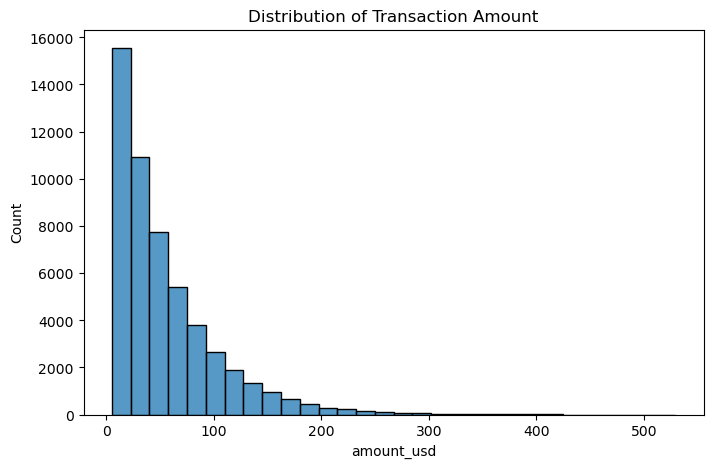

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['amount_usd'], bins=30)

plt.title("Distribution of Transaction Amount")
plt.show()

The transaction amount distribution is positively skewed, with most transactions concentrated at lower values and a long tail extending toward higher amounts. This suggests that while the majority of users make relatively small transactions, a few transactions involve substantially larger amounts. Since fraud is often associated with unusual spending behavior, transaction amount is likely to be an important predictive feature and will be retained for modeling.

## Transaction Amount Outliers

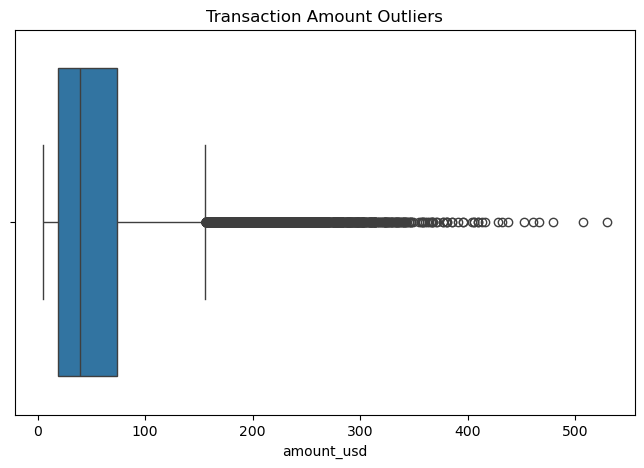

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['amount_usd'])

plt.title("Transaction Amount Outliers")
plt.show()

A considerable number of high-value transaction outliers are present in the dataset. These outliers may represent legitimate large purchases or potentially suspicious activities. Rather than removing them, they will be retained because extreme transaction values can contain valuable fraud-related information.

## Amount by Fraud Status

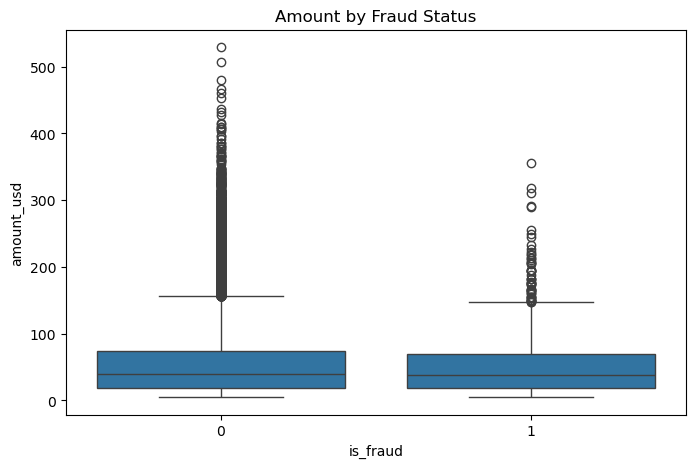

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_fraud',
    y='amount_usd'
)

plt.title("Amount by Fraud Status")
plt.show()

Fraudulent and legitimate transactions exhibit similar transaction amount distributions, with comparable median values and interquartile ranges. This suggests that transaction amount alone may not be sufficient to distinguish fraudulent transactions. Additional behavioral and transactional features will likely be required to improve fraud detection performance.

## Transactions by Card Country

In [20]:
df['card_country'].value_counts()

card_country
NG    31638
US     7847
GB     5290
KE     2579
ZA     2576
GH     2570
Name: count, dtype: int64

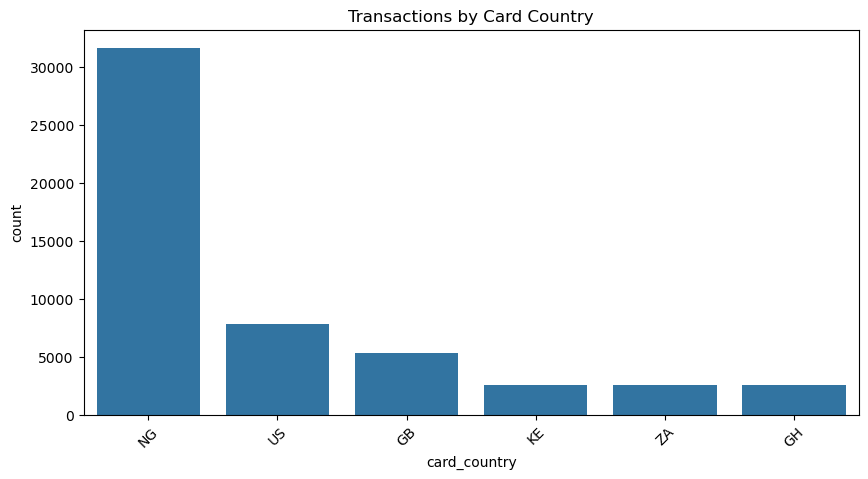

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='card_country',
    order=df['card_country'].value_counts().index
)

plt.title("Transactions by Card Country")
plt.xticks(rotation=45)

plt.show()

The majority of transactions originate from Nigeria (NG), accounting for a substantially larger share of the dataset than all other countries. This indicates an uneven geographic distribution of transactions, with Nigeria representing the primary market. Since transaction behavior may vary across countries, `card_country` will be retained as a predictive feature during modeling.

## Average Fraud Rate by Countries

In [22]:
country_fraud_mean = (
    df.groupby('card_country')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

country_fraud_mean

card_country
US    0.021664
GB    0.020605
KE    0.019000
NG    0.018427
ZA    0.018245
GH    0.016342
Name: is_fraud, dtype: float64

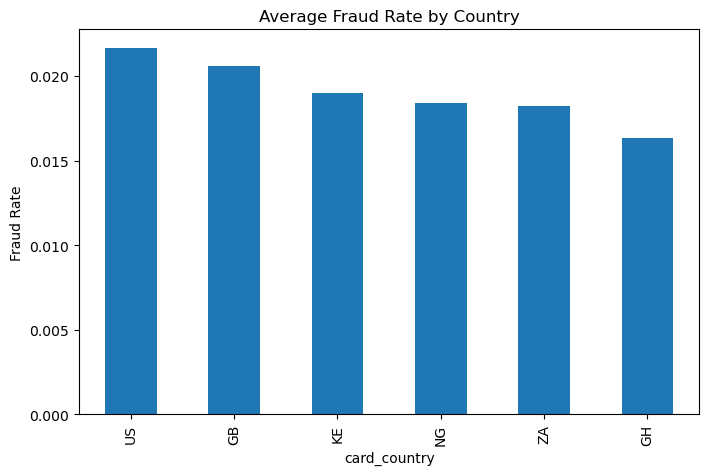

In [23]:
plt.figure(figsize = (8,5))
country_fraud_mean.plot(kind='bar')

plt.title("Average Fraud Rate by Country")
plt.ylabel("Fraud Rate")

plt.show()

Fraud rates are relatively similar across all countries, ranging from approximately 1.6% to 2.2%. Although the United States and the United Kingdom exhibit slightly higher fraud rates, the differences are not substantial. This suggests that country alone may have limited predictive power, but it may become more informative when combined with other transaction and behavioral features.

## Merchant Category Distribution

In [24]:
df['merchant_category'].value_counts()

merchant_category
ecommerce        20817
utility          13269
digital_goods    10562
travel            5190
crypto            2662
Name: count, dtype: int64

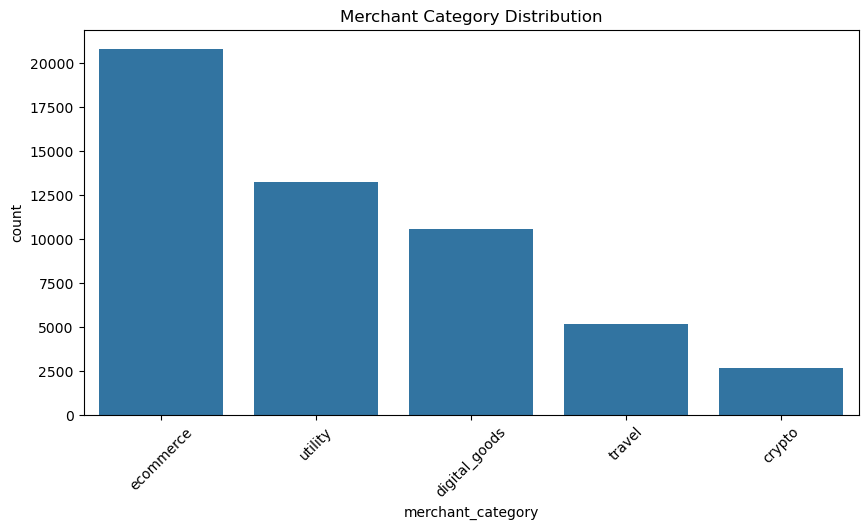

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='merchant_category',
    order=df['merchant_category'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Merchant Category Distribution")

plt.show()

E-commerce transactions account for the largest share of activity, followed by utility and digital goods transactions. Travel and crypto transactions occur less frequently in comparison. The variation in transaction volume across merchant categories suggests that customer behavior differs by merchant type, making `merchant_category` a potentially useful feature for fraud detection.

## Fraud Rate by Merchant Category

In [26]:
merchant_fraud = (
    df.groupby('merchant_category')['is_fraud']
    .mean()
    .sort_values(ascending=False)
)

merchant_fraud

merchant_category
ecommerce        0.019936
utility          0.019368
digital_goods    0.018652
travel           0.017341
crypto           0.015402
Name: is_fraud, dtype: float64

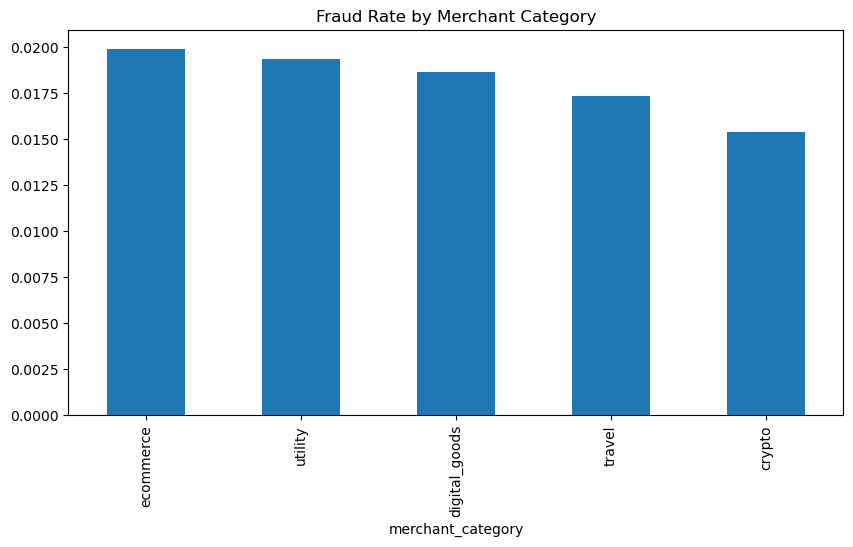

In [27]:
plt.figure(figsize=(10,5))
merchant_fraud.plot(kind='bar')

plt.title("Fraud Rate by Merchant Category")

plt.show()

Fraud rates are fairly consistent across merchant categories, with e-commerce and utility transactions showing slightly higher fraud rates than the other categories. Although the differences are relatively small, merchant category may still contribute useful information when combined with other features during model development.

In [28]:
df['device_id'].value_counts().head(10)

device_id
DEV_77859    8
DEV_95971    8
DEV_10160    7
DEV_57886    7
DEV_64811    6
DEV_75480    6
DEV_91918    6
DEV_49242    6
DEV_21766    6
DEV_41729    6
Name: count, dtype: int64

# Feature Engineering

The `hour`, `day`, and `day_of_week` features were extracted from the transaction timestamp to capture temporal transaction patterns. Fraudulent activities often exhibit time-based behaviors, such as occurring at specific hours or days. These engineered features may help the model identify patterns that are not directly observable from the raw timestamp field.

In [29]:
df['hour'] = df['timestamp'].dt.hour

df['day'] = df['timestamp'].dt.day

df['day_of_week'] = df['timestamp'].dt.day_name()

In [30]:
df.head()

,transaction_id,user_id,timestamp,amount_usd,card_country,merchant_category,device_id,dispute_status,is_fraud,hour,day,day_of_week
0,3c4b12fa-07e5-4bc5-89f2-0fbbef5bb621,USR_7270,2026-05-24 07:56:29,13.03,NG,digital_goods,DEV_84432,none,0,7,24,Sunday
1,45cec382-3988-4e49-9069-ec067fae3211,USR_9970,2026-05-30 00:00:04,25.45,NG,ecommerce,DEV_71903,none,0,0,30,Saturday
2,f89e3f53-c7fa-44ab-8d4d-7e0f18e3ee85,USR_1927,2026-05-27 19:07:33,31.07,NG,digital_goods,DEV_43762,none,0,19,27,Wednesday
3,bdfa52db-f96a-4446-9108-fa5a415c1499,USR_2602,2026-05-06 21:49:19,36.46,NG,ecommerce,DEV_65740,none,0,21,6,Wednesday
4,724f928e-36f9-4018-9671-6c247c6f6000,USR_1434,2026-05-13 07:10:28,140.66,NG,travel,DEV_74609,none,0,7,13,Wednesday


## Transactions by hour

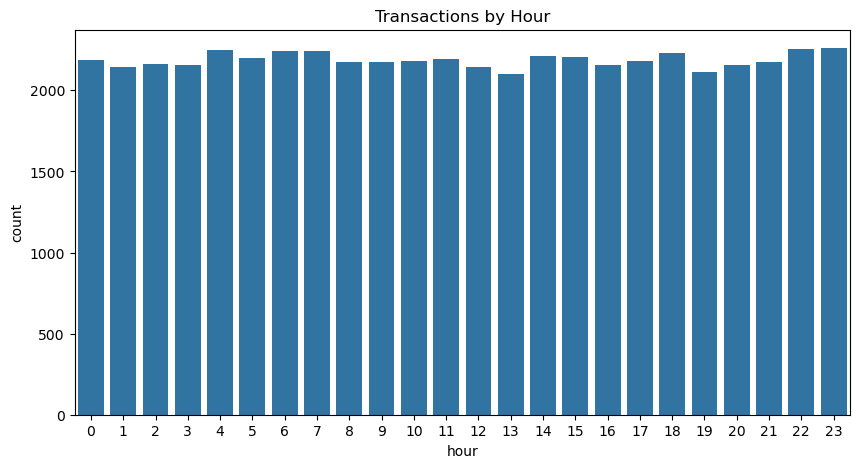

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='hour'
)

plt.title("Transactions by Hour")

plt.show()

Transaction volume is relatively consistent throughout the day, with no significant spikes or drops across the 24-hour period. This suggests that transaction activity is well distributed over time and that users transact throughout the day.

## Fraud rate by hour

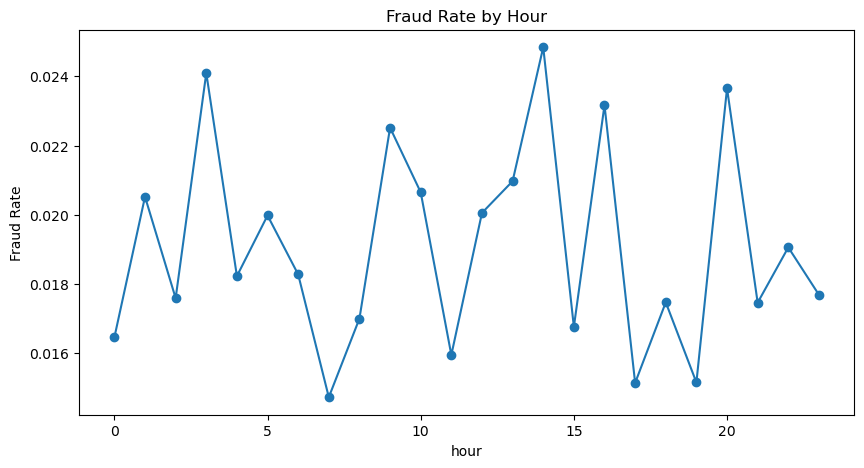

In [32]:
plt.figure(figsize=(10,5))
fraud_hour = (
    df.groupby('hour')['is_fraud']
    .mean()
)

fraud_hour.plot(marker='o')

plt.title("Fraud Rate by Hour")

plt.ylabel("Fraud Rate")

plt.show()

The fraud rate varies slightly across different hours of the day, with some hours exhibiting higher fraud activity than others. this indicates that the time of transaction may contain useful information for distinguishing fraudulent transactions.

## Transactions by day

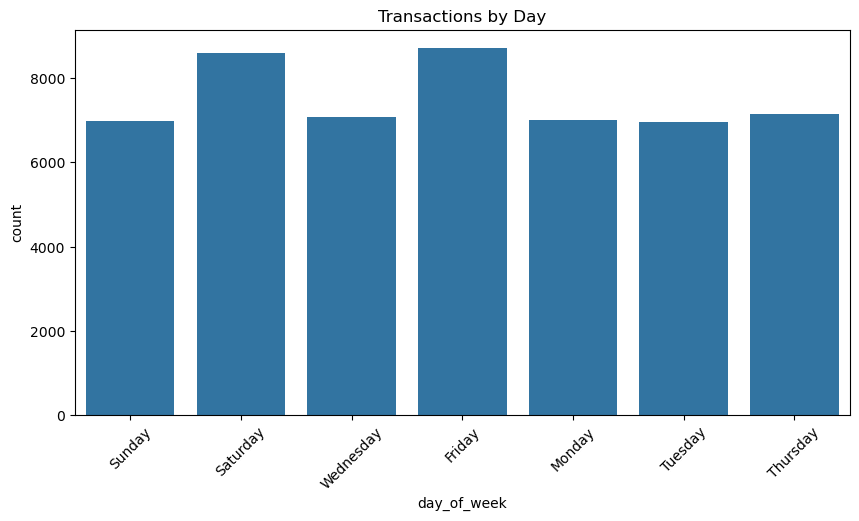

In [33]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='day_of_week'
)

plt.xticks(rotation=45)

plt.title("Transactions by Day")

plt.show()

Transaction activity is fairly evenly distributed across the days of the week, with slightly higher transaction volumes observed on Fridays and Saturdays. This suggests that users remain consistently active throughout the week, although transaction behavior may increase marginally towards the weekend.

## Correlation Analysis

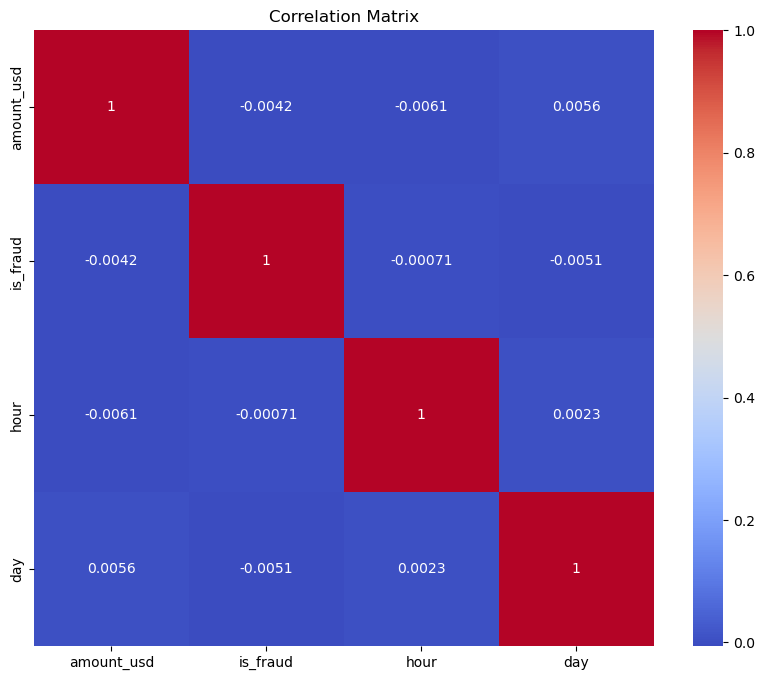

In [34]:
num_cols = df.select_dtypes('number')

corr = num_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows very weak linear relationships among the numerical variables, with all correlation coefficients close to zero. In particular, transaction amount, hour, and day exhibit little direct correlation with the fraud target variable.

This suggests that fraudulent transactions are unlikely to be explained by any single numerical feature alone. Consequently, the model will rely on a combination of features and patterns rather than strong individual correlations to identify fraudulent behavior.

In [35]:
df.groupby('is_fraud').agg({
    'amount_usd':['mean','median','max','count']
})

amount_usd                      
               mean median     max  count
is_fraud                                 
0         54.825034  39.60  529.43  51500
1         53.298200  38.28  356.21   1000

# Feature engineering contd.

In [36]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

Fraud patterns sometimes differ between weekdays and weekends. This is why a feature is created to distinguish between weekday and weekend transactions

In [37]:
df.head()

,transaction_id,user_id,timestamp,amount_usd,card_country,merchant_category,device_id,dispute_status,is_fraud,hour,day,day_of_week,is_weekend
0,3c4b12fa-07e5-4bc5-89f2-0fbbef5bb621,USR_7270,2026-05-24 07:56:29,13.03,NG,digital_goods,DEV_84432,none,0,7,24,Sunday,1
1,45cec382-3988-4e49-9069-ec067fae3211,USR_9970,2026-05-30 00:00:04,25.45,NG,ecommerce,DEV_71903,none,0,0,30,Saturday,1
2,f89e3f53-c7fa-44ab-8d4d-7e0f18e3ee85,USR_1927,2026-05-27 19:07:33,31.07,NG,digital_goods,DEV_43762,none,0,19,27,Wednesday,0
3,bdfa52db-f96a-4446-9108-fa5a415c1499,USR_2602,2026-05-06 21:49:19,36.46,NG,ecommerce,DEV_65740,none,0,21,6,Wednesday,0
4,724f928e-36f9-4018-9671-6c247c6f6000,USR_1434,2026-05-13 07:10:28,140.66,NG,travel,DEV_74609,none,0,7,13,Wednesday,0


In [38]:
threshold = df['amount_usd'].quantile(0.95)

df['high_amount'] = (df['amount_usd'] > threshold).astype(int)

Most times, fraudsters make unusually large transactions. This feature will help us to identify high amount transactions

In [39]:
user_txn_count = df['user_id'].value_counts()

df['user_transaction_count'] = df['user_id'].map(user_txn_count)

New or infrequent users sometimes exhibit different risk profiles.

In [40]:
df['user_transaction_count'].value_counts()

user_transaction_count
6     8124
7     8057
5     7430
8     6592
9     5175
4     5104
10    3610
3     2643
11    2167
12    1200
2      984
13     689
14     336
1      186
15     120
17      51
16      32
Name: count, dtype: int64

In [41]:
df.head()

,transaction_id,user_id,timestamp,amount_usd,card_country,merchant_category,device_id,dispute_status,is_fraud,hour,day,day_of_week,is_weekend,high_amount,user_transaction_count
0,3c4b12fa-07e5-4bc5-89f2-0fbbef5bb621,USR_7270,2026-05-24 07:56:29,13.03,NG,digital_goods,DEV_84432,none,0,7,24,Sunday,1,0,4
1,45cec382-3988-4e49-9069-ec067fae3211,USR_9970,2026-05-30 00:00:04,25.45,NG,ecommerce,DEV_71903,none,0,0,30,Saturday,1,0,9
2,f89e3f53-c7fa-44ab-8d4d-7e0f18e3ee85,USR_1927,2026-05-27 19:07:33,31.07,NG,digital_goods,DEV_43762,none,0,19,27,Wednesday,0,0,6
3,bdfa52db-f96a-4446-9108-fa5a415c1499,USR_2602,2026-05-06 21:49:19,36.46,NG,ecommerce,DEV_65740,none,0,21,6,Wednesday,0,0,4
4,724f928e-36f9-4018-9671-6c247c6f6000,USR_1434,2026-05-13 07:10:28,140.66,NG,travel,DEV_74609,none,0,7,13,Wednesday,0,0,5


In [42]:
device_count = df['device_id'].value_counts()

df['device_usage_count'] = df['device_id'].map(device_count)

Devices used unusually often can indicate suspicious behavior.

In [43]:
df['device_usage_count'].value_counts()

device_usage_count
1    27175
2    17418
3     5979
4     1588
5      250
6       60
8       16
7       14
Name: count, dtype: int64

## Data Preprocessing

In [44]:
#defining my target variable
y = df['is_fraud']

Below, i will drop some columns that will not be included in model training

In [45]:
X = df.drop(columns = ["transaction_id", "timestamp", "user_id", "device_id", "is_fraud"])

I dropped the above features from X araay because
- transaction_id is just an identifier
- timestamp already represented by hour/day/day_of_week
- user_id and device_id have very high cardinality
- is_fraud is my target feature

In [46]:
X.head()

,amount_usd,card_country,merchant_category,dispute_status,hour,day,day_of_week,is_weekend,high_amount,user_transaction_count,device_usage_count
0,13.03,NG,digital_goods,none,7,24,Sunday,1,0,4,1
1,25.45,NG,ecommerce,none,0,30,Saturday,1,0,9,1
2,31.07,NG,digital_goods,none,19,27,Wednesday,0,0,6,1
3,36.46,NG,ecommerce,none,21,6,Wednesday,0,0,4,1
4,140.66,NG,travel,none,7,13,Wednesday,0,0,5,1


In [47]:
categorical_cols = [
    'card_country',
    'merchant_category',
    'dispute_status',
    'day_of_week'
]

numerical_cols = [
    'amount_usd',
    'hour',
    'day',
    'is_weekend',
    'high_amount',
    'user_transaction_count',
    'device_usage_count'
]

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ]
)

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

# Model Training

I chose to use RandomForest Classifier, imported above becasue of it high predictive power and ability to perform well on imbalanced dataset.

In [52]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount_usd', 'hour', 'day',
                                                   'is_weekend', 'high_amount',
                                                   'user_transaction_count',
                                                   'device_usage_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['card_country',
                                                   'merchant_category',
                                                   'dispute_status',
                                                   'day_of_week'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

# Model Evaluation

In [53]:
y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

In [54]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     10300
           1       1.00      0.68      0.81       200

    accuracy                           0.99     10500
   macro avg       1.00      0.84      0.90     10500
weighted avg       0.99      0.99      0.99     10500



The Random Forest model achieved an overall accuracy of 99%. For the fraud class, the model achieved a precision of 100%, recall of 68%, and an F1-score of 81%.

The perfect precision indicates that every transaction flagged as fraudulent was indeed fraudulent, resulting in no false positives. However, the recall of 68% suggests that approximately one-third of fraudulent transactions were not detected. In fraud detection, recall is particularly important because missed fraud cases can lead to financial losses. Overall, the model demonstrates strong predictive performance while maintaining a good balance between fraud detection and false alarm reduction.

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[10300,     0],
       [   64,   136]])

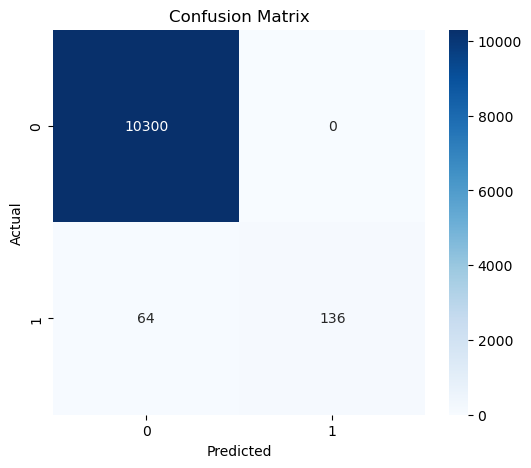

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

The confusion matrix shows that all 10,300 legitimate transactions were correctly classified, while 136 out of 200 fraudulent transactions were successfully detected. Only 64 fraudulent transactions were incorrectly classified as legitimate.

The absence of false positives indicates that the model is highly conservative when predicting fraud. While this minimizes disruptions to legitimate customers, further improvements could focus on increasing fraud recall to reduce the number of missed fraudulent transactions.

In [58]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_pred_proba
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8843259708737865


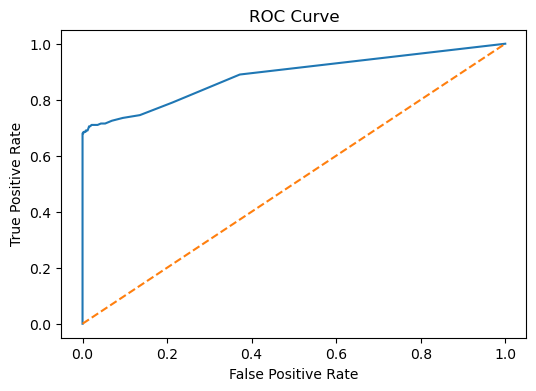

In [59]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

The model achieved a ROC-AUC score of 0.884, indicating a strong ability to distinguish between fraudulent and legitimate transactions. The ROC curve lies above the random classification line, confirming that the model captures meaningful fraud-related patterns within the dataset.

An AUC value close to 0.9 suggests that the model provides good discriminatory power and can serve as a reliable baseline for fraud detection.

# Feature Importance

In [60]:
feature_names = (
    numerical_cols +
    list(
        model.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_cols)
    )
)

In [61]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.named_steps['classifier'].feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
18,dispute_status_chargeback_won,0.159025
19,dispute_status_inquiry,0.156593
21,dispute_status_pending,0.126980
0,amount_usd,0.106418
20,dispute_status_none,0.090997
1,hour,0.077464
5,user_transaction_count,0.064192
2,day,0.054192
6,device_usage_count,0.027876
15,merchant_category_ecommerce,0.011548


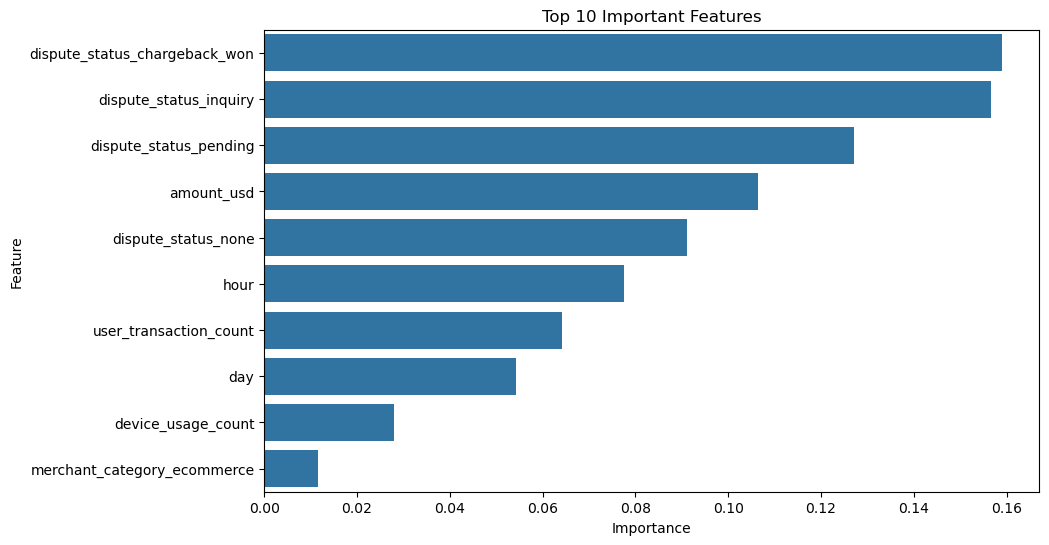

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

The feature importance analysis reveals that dispute status variables are the strongest predictors of fraud, followed by transaction amount, transaction hour, user transaction count, and day of transaction.

Transaction amount and user behavioral features contribute meaningfully to the model's decisions, suggesting that both transaction characteristics and customer activity patterns are relevant indicators of fraud risk. Merchant category and device usage appear to have a comparatively smaller influence on model performance.

# Conclusion

In this project, I developed a machine learning solution for detecting fraudulent transactions using transaction, customer, device, geographic, and time-based information. Exploratory data analysis revealed class imbalance within the dataset and provided insights into transaction patterns across countries, merchant categories, and transaction times.

Additional features were engineered from transaction timestamps and user/device activity to improve the model's ability to identify potentially fraudulent behaviour. A Random Forest classifier was then trained and evaluated using standard classification metrics.

The final model achieved an overall accuracy of 99%, a fraud detection precision of 100%, a recall of 68%, and a ROC-AUC score of 0.884. These results indicate that the model was effective at identifying fraudulent transactions while maintaining a very low false-positive rate.

The analysis demonstrates how data exploration, feature engineering, and machine learning can be combined to support fraud detection and risk management in digital payment systems.
